In [131]:
import pandas as pd
import numpy as np
import minsearch
from dotenv import load_dotenv
import os 
from openai import OpenAI
from tqdm.auto import tqdm
import json
import matplotlib.pyplot as plt
import seaborn as sns
from groq import Groq

load_dotenv()
client = OpenAI(api_key=os.environ.get("OPENAI_API_KEY"))
client_groq = Groq(api_key=os.environ.get("GROQ_API_KEY"))

## Data Ingestion

In [75]:
data = pd.read_csv('data/Mental_Health_FAQ.csv', index_col=False)
data = data.rename(columns={'Question_ID': 'question_id', 'Questions': 'questions', 'Answers': 'answers'})
data.head()

,question_id,questions,answers
0,1590140,What does it mean to have a mental illness?,Mental illnesses are health conditions that di...
1,2110618,Who does mental illness affect?,It is estimated that mental illness affects 1 ...
2,6361820,What causes mental illness?,It is estimated that mental illness affects 1 ...
3,9434130,What are some of the warning signs of mental i...,Symptoms of mental health disorders vary depen...
4,7657263,Can people with mental illness recover?,"When healing from mental illness, early identi..."


In [76]:
data.head(10)

,question_id,questions,answers
0,1590140,What does it mean to have a mental illness?,Mental illnesses are health conditions that di...
1,2110618,Who does mental illness affect?,It is estimated that mental illness affects 1 ...
2,6361820,What causes mental illness?,It is estimated that mental illness affects 1 ...
3,9434130,What are some of the warning signs of mental i...,Symptoms of mental health disorders vary depen...
4,7657263,Can people with mental illness recover?,"When healing from mental illness, early identi..."
5,1619387,What should I do if I know someone who appears...,Although this website cannot substitute for pr...
6,1030153,How can I find a mental health professional fo...,Feeling comfortable with the professional you ...
7,8022026,What treatment options are available?,Just as there are different types of medicatio...
8,1155199,"If I become involved in treatment, what do I n...",Since beginning treatment is a big step for in...
9,7760466,What is the difference between mental health p...,There are many types of mental health professi...


In [77]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 98 entries, 0 to 97
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   question_id  98 non-null     int64 
 1   questions    98 non-null     object
 2   answers      98 non-null     object
dtypes: int64(1), object(2)
memory usage: 2.4+ KB


In [78]:
documents = data.to_dict(orient='records')

In [79]:
documents[10]

{'question_id': 2553795,
 'questions': 'How can I find a mental health professional right for my child or myself?',
 'answers': 'Feeling comfortable with the professional you or your child is working with is critical to the success of your treatment. Finding the professional who best fits your needs may require some research.'}

## Index Document with Minsearch

In [80]:
index = minsearch.Index(text_fields=['questions', 'answers'], keyword_fields=[])

In [81]:
index.fit(documents)

In [82]:
query='What is the difference between a psychologist and a psychiatrist?'

In [83]:
index.search(query)

[{'question_id': 6851366,
  'questions': "What's the difference between a psychiatrist and a registered psychologist?",
  'answers': 'A psychiatrist is a medical doctor with extra training in mental health who can choose to prescribe medications. Some use psychotherapy (‘talk therapies’) approaches like cognitive-behavioural therapy to treat mental health problems. Many psychiatrists work at hospitals, clinics, or health centres, and some have a private office. As they are specialist doctors, you will almost always need another doctor’s referral to see a psychiatrist, and fees are covered by MSP. If you have a valid BC Services or CareCard, you do not need to pay to see a psychiatrist. \n A registered psychologist focuses on different talk therapy or counselling approaches to treatments, but they don’t prescribe medication. They have graduate degrees in psychology. There are two different ways to access registered psychologists: the public system and the private system. Registered psyc

## Evaluating Retrieval

In [84]:
questions = pd.read_csv('../mentalhealthqa/data/ground_truth_data.csv')

In [85]:
questions.head(10)

,id,question
0,1590140,How do mental conditions affect daily life and...
1,1590140,What is the range of severity for mental illne...
2,1590140,What serious disorders require hospital care?
3,1590140,How are mental illnesses similar to physical h...
4,1590140,What treatments are effective for managing men...
5,2110618,How many adults in America are affected by men...
6,2110618,Can you explain how mental illness impacts dif...
7,2110618,What age groups are particularly vulnerable to...
8,2110618,Why is it challenging to identify mental healt...
9,2110618,What signs should parents look for to detect m...


In [86]:
ground_truth = questions.to_dict(orient='records')
ground_truth[10]

{'id': 6361820,
 'question': 'How common is mental illness among adults in America?'}

In [87]:
def hit_rate(relevance_total):
    count=0
    for i in relevance_total:
        if True in i:
            count= count + 1
    return count / len(relevance_total)

In [88]:
def mrr(relevance_total):
    total_score = 0.0
    for i in relevance_total:
        for rank in range(len(i)):
            if i[rank]== True:
                total_score= total_score + 1 / (rank + 1)
    return total_score / len(relevance_total)

In [89]:
def minsearch_search(query):
    boost = {}

    results = index.search(
        query=query,
        filter_dict={},
        boost_dict=boost,
        num_results=5
    )

    return results

In [90]:
def precision(rel_list):
    
    true_retrieved= sum(rel_list)
    total_retrieved= len(rel_list)
    if total_retrieved==0:
        return 0.0
    return true_retrieved / total_retrieved

In [91]:
def recall(rel_list, total_retrieved):
    # ratio of relevant documents that were succesfully retrieved
    true_list= sum(rel_list)
    if total_retrieved == 0:
        return 0.0
    return true_list / total_retrieved

In [92]:
def evaluate(ground_truth, search_func):
    relevance_total = []
    precision_scores=[]
    recall_scores=[]
    for i in tqdm(ground_truth):
        document_id = i['id']
        results = search_func(i)
        # check if the correct document is in the results (check by matching id)
        relevance = [r['question_id'] == document_id for r in results]
        relevance_total.append(relevance)

        # precision: the portion of retrieved documenst that are relevant
        precision_score = precision(relevance)
        precision_scores.append(precision_score)

        # recall: here recall is either 1 or 0, since it is only one relevant doc per query
        recall_score= recall(relevance, 1)
        recall_scores.append(recall_score)
    return {'hit_rate': hit_rate(relevance_total), 'mrr': mrr(relevance_total), 'precision': sum(precision_scores)/ len(precision_scores), 'recall': sum(recall_scores)/len(recall_scores)}

In [93]:
evaluate(ground_truth, lambda q: minsearch_search(q['question']))

  0%|          | 0/490 [00:00<?, ?it/s]

{'hit_rate': 0.6775510204081633,
 'mrr': 0.49346938775510196,
 'precision': 0.13551020408163347,
 'recall': 0.6775510204081633}

Evaluate shows we have a relatively high recall and low precision, this suggests the system is finding most of the relavant documents but we still retrieving a lot of irrelevant ones, i have to improve both the precision by tuning the seacrh algorithm, adjusting boostinf and filtering irrelevant ones.

## RAG LOGIC

In [94]:
def search(query):
    boost= {}
    results = index.search(query=query, filter_dict={}, boost_dict=boost, num_results=5)
    return results

In [95]:
template="""
You are an expert mental health assistant specialized in providing detailed and accurate answers based on the given context.
Answer the QUESTION based on the CONTEXT from our mental health database.
Use only the facts from the CONTEXT when answering the QUESTION.

Here is the context:

Context: {context}

Please answer the following question based on the provided context:

Question: {question}

Provide a detailed and informative response. Ensure that your answer is clear, concise, and directly addresses the question while being relevant to the context provided.

Your response should be in plain text and should not include any code blocks or extra formatting.

Answer:
""".strip()

In [96]:
def build_prompt(query, search_results):
    context= ""
    for doc in search_results:
        context = context.format(**doc) + '\n\n'
    prompt = template.format(question=query, context=context).strip()
    return prompt

In [97]:
def llm(prompt, model):
    response= client.chat.completions.create(model=model, messages=[{"role": "user", "content": prompt}])
    return response.choices[0].message.content

In [98]:
def rag(query, model='gpt-4o-mini'):
    search_results = search(query)
    prompt = build_prompt(query, search_results)
    #print(prompt)
    answer = llm(prompt, model=model)
    return answer


In [99]:
question = 'How common is mental illness among adults in America?'
answer = rag(question)
print(answer)

The context provided does not include specific information regarding the prevalence of mental illness among adults in America. Therefore, I am unable to provide a detailed and informative response based on the given context. If you have specific data or additional information on this topic, please share it, and I can help you analyze or summarize it.


## RAG Evaluation

In [100]:
template_2=  """
You are an expert evaluator for a RAG system.
Your task is to analyze the relevance of the generated answer to the given question.
Based on the relevance of the generated answer, you will classify it
as "NON_RELEVANT", "PARTLY_RELEVANT", or "RELEVANT".

Here is the data for evaluation:

Question: {question}
Generated Answer: {answer_llm}

Please analyze the content and context of the generated answer in relation to the question
and provide your evaluation in parsable JSON without using code blocks:

{{
  "Relevance": "NON_RELEVANT" | "PARTLY_RELEVANT" | "RELEVANT",
  "Explanation": "[Provide a summary for your evaluation]"
}}
""".strip()

In [101]:
len(ground_truth)

490

In [102]:
ground_truth[10]

{'id': 6361820,
 'question': 'How common is mental illness among adults in America?'}

In [103]:
record = ground_truth[10]
q = record['question']
# print(q)
answer_llm = rag(q)

In [104]:
prompt_2= template_2.format(question=q,answer_llm=answer_llm)
print(prompt_2)

You are an expert evaluator for a RAG system.
Your task is to analyze the relevance of the generated answer to the given question.
Based on the relevance of the generated answer, you will classify it
as "NON_RELEVANT", "PARTLY_RELEVANT", or "RELEVANT".

Here is the data for evaluation:

Question: How common is mental illness among adults in America?
Generated Answer: The context provided does not contain specific information regarding the prevalence of mental illness among adults in America. Therefore, I cannot provide a detailed answer about how common mental illness is among adults in this region based solely on the provided context. If you have additional information or another context to reference, please share it, and I will do my best to assist you.

Please analyze the content and context of the generated answer in relation to the question
and provide your evaluation in parsable JSON without using code blocks:

{
  "Relevance": "NON_RELEVANT" | "PARTLY_RELEVANT" | "RELEVANT",
  "

In [ ]:
record = ground_truth[0]
q = record['question']
# print(q)
answer_llm = rag(q)

How do mental conditions affect daily life and relationships?


In [106]:
prompt_2= template_2.format(question=q,answer_llm=answer_llm)
print(prompt_2)

You are an expert evaluator for a RAG system.
Your task is to analyze the relevance of the generated answer to the given question.
Based on the relevance of the generated answer, you will classify it
as "NON_RELEVANT", "PARTLY_RELEVANT", or "RELEVANT".

Here is the data for evaluation:

Question: How do mental conditions affect daily life and relationships?
Generated Answer: Mental conditions can significantly affect daily life and relationships in various ways. Individuals with mental health issues may experience challenges in managing their daily activities, such as maintaining a consistent routine, performing at work or school, and fulfilling household responsibilities. Symptoms like fatigue, lack of motivation, or difficulty concentrating can hinder productivity and lead to missed opportunities or tasks.

In relationships, mental health struggles can lead to communication problems, misunderstandings, and emotional distance. Individuals may find it challenging to express their feeli

In [109]:
evaluations=[]
for record in tqdm(ground_truth):
    doc_id=record['id']
    if id in evaluations:
        continue
    question=record['question']
    llm_answer=rag(question)
    prompt=template_2.format(question=question, answer_llm=llm_answer)
    evaluation=llm(prompt, model='gpt-4o-mini')
    eval= json.loads(evaluation)
    evaluations.append((record, llm_answer, eval))

  0%|          | 0/490 [00:00<?, ?it/s]

In [112]:
df_eval= pd.DataFrame(evaluations, columns=['record', 'answer', 'evaluation'])

In [113]:
df_eval.head()

,record,answer,evaluation
0,"{'id': 1590140, 'question': 'How do mental con...",Mental conditions can significantly impact dai...,"{'Relevance': 'RELEVANT', 'Explanation': 'The ..."
1,"{'id': 1590140, 'question': 'What is the range...",The range of severity for mental illnesses can...,"{'Relevance': 'RELEVANT', 'Explanation': 'The ..."
2,"{'id': 1590140, 'question': 'What serious diso...",The context provided does not contain specific...,"{'Relevance': 'PARTLY_RELEVANT', 'Explanation'..."
3,"{'id': 1590140, 'question': 'How are mental il...",Mental illnesses are similar to physical healt...,"{'Relevance': 'RELEVANT', 'Explanation': 'The ..."
4,"{'id': 1590140, 'question': 'What treatments a...",The provided context does not include any spec...,"{'Relevance': 'NON_RELEVANT', 'Explanation': '..."


In [114]:
df_eval['id'] = df_eval.record.apply(lambda doc: doc['id'])
df_eval['question'] = df_eval.record.apply(lambda doc: doc['question'])
df_eval['relevance'] = df_eval.evaluation.apply(lambda doc: doc['Relevance'])
df_eval['explanation'] = df_eval.evaluation.apply(lambda doc: doc['Explanation'])



In [115]:
df_eval.head(10)

,record,answer,evaluation,id,question,relevance,explanation
0,"{'id': 1590140, 'question': 'How do mental con...",Mental conditions can significantly impact dai...,"{'Relevance': 'RELEVANT', 'Explanation': 'The ...",1590140,How do mental conditions affect daily life and...,RELEVANT,The generated answer effectively addresses the...
1,"{'id': 1590140, 'question': 'What is the range...",The range of severity for mental illnesses can...,"{'Relevance': 'RELEVANT', 'Explanation': 'The ...",1590140,What is the range of severity for mental illne...,RELEVANT,The generated answer addresses the question di...
2,"{'id': 1590140, 'question': 'What serious diso...",The context provided does not contain specific...,"{'Relevance': 'PARTLY_RELEVANT', 'Explanation'...",1590140,What serious disorders require hospital care?,PARTLY_RELEVANT,The generated answer acknowledges the lack of ...
3,"{'id': 1590140, 'question': 'How are mental il...",Mental illnesses are similar to physical healt...,"{'Relevance': 'RELEVANT', 'Explanation': 'The ...",1590140,How are mental illnesses similar to physical h...,RELEVANT,The generated answer effectively addresses the...
4,"{'id': 1590140, 'question': 'What treatments a...",The provided context does not include any spec...,"{'Relevance': 'NON_RELEVANT', 'Explanation': '...",1590140,What treatments are effective for managing men...,NON_RELEVANT,The generated answer states that it cannot pro...
5,"{'id': 2110618, 'question': 'How many adults i...",The provided context does not contain any spec...,"{'Relevance': 'NON_RELEVANT', 'Explanation': '...",2110618,How many adults in America are affected by men...,NON_RELEVANT,The generated answer states that it lacks spec...
6,"{'id': 2110618, 'question': 'Can you explain h...",The context provided does not contain specific...,"{'Relevance': 'NON_RELEVANT', 'Explanation': '...",2110618,Can you explain how mental illness impacts dif...,NON_RELEVANT,The generated answer acknowledges the lack of ...
7,"{'id': 2110618, 'question': 'What age groups a...",The context is missing specific information re...,"{'Relevance': 'RELEVANT', 'Explanation': 'The ...",2110618,What age groups are particularly vulnerable to...,RELEVANT,The generated answer identifies specific age g...
8,"{'id': 2110618, 'question': 'Why is it challen...",It can be challenging to identify mental healt...,"{'Relevance': 'RELEVANT', 'Explanation': 'The ...",2110618,Why is it challenging to identify mental healt...,RELEVANT,The generated answer directly addresses the qu...
9,"{'id': 2110618, 'question': 'What signs should...",Parents should look for several signs that may...,"{'Relevance': 'RELEVANT', 'Explanation': 'The ...",2110618,What signs should parents look for to detect m...,RELEVANT,The generated answer provides a comprehensive ...


In [116]:
del df_eval['record']
del df_eval['evaluation']

In [117]:
df_eval.head(10)

,answer,id,question,relevance,explanation
0,Mental conditions can significantly impact dai...,1590140,How do mental conditions affect daily life and...,RELEVANT,The generated answer effectively addresses the...
1,The range of severity for mental illnesses can...,1590140,What is the range of severity for mental illne...,RELEVANT,The generated answer addresses the question di...
2,The context provided does not contain specific...,1590140,What serious disorders require hospital care?,PARTLY_RELEVANT,The generated answer acknowledges the lack of ...
3,Mental illnesses are similar to physical healt...,1590140,How are mental illnesses similar to physical h...,RELEVANT,The generated answer effectively addresses the...
4,The provided context does not include any spec...,1590140,What treatments are effective for managing men...,NON_RELEVANT,The generated answer states that it cannot pro...
5,The provided context does not contain any spec...,2110618,How many adults in America are affected by men...,NON_RELEVANT,The generated answer states that it lacks spec...
6,The context provided does not contain specific...,2110618,Can you explain how mental illness impacts dif...,NON_RELEVANT,The generated answer acknowledges the lack of ...
7,The context is missing specific information re...,2110618,What age groups are particularly vulnerable to...,RELEVANT,The generated answer identifies specific age g...
8,It can be challenging to identify mental healt...,2110618,Why is it challenging to identify mental healt...,RELEVANT,The generated answer directly addresses the qu...
9,Parents should look for several signs that may...,2110618,What signs should parents look for to detect m...,RELEVANT,The generated answer provides a comprehensive ...


In [118]:
print(df_eval['relevance'].value_counts())

relevance
RELEVANT           381
NON_RELEVANT        65
PARTLY_RELEVANT     44
Name: count, dtype: int64


C:\Users\HP\AppData\Local\Temp\ipykernel_48456\620821810.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_eval, x='relevance', palette='viridis')


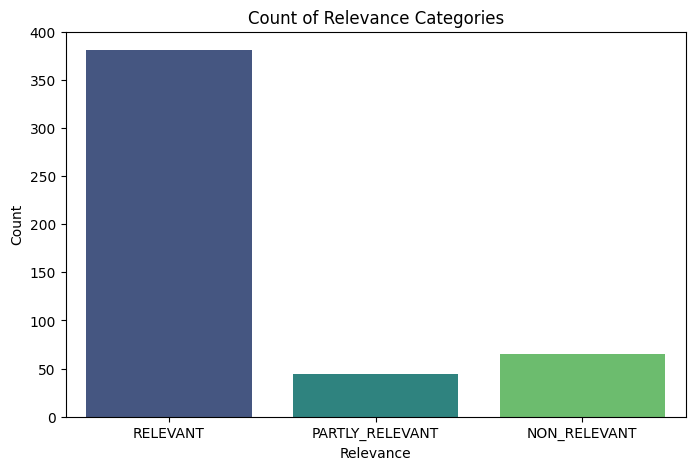

In [121]:
plt.figure(figsize=(8, 5))
sns.countplot(data=df_eval, x='relevance', palette='viridis')
plt.title('Count of Relevance Categories')
plt.xlabel('Relevance')
plt.ylabel('Count')
plt.show()

In [127]:
relevant_answers = df_eval[df_eval['relevance']=='RELEVANT']
relevant_answers[['question', 'answer', 'explanation']]

,question,answer,explanation
0,How do mental conditions affect daily life and...,Mental conditions can significantly impact dai...,The generated answer effectively addresses the...
1,What is the range of severity for mental illne...,The range of severity for mental illnesses can...,The generated answer addresses the question di...
3,How are mental illnesses similar to physical h...,Mental illnesses are similar to physical healt...,The generated answer effectively addresses the...
7,What age groups are particularly vulnerable to...,The context is missing specific information re...,The generated answer identifies specific age g...
8,Why is it challenging to identify mental healt...,It can be challenging to identify mental healt...,The generated answer directly addresses the qu...
...,...,...,...
474,How can communities have productive conversati...,To facilitate productive conversations about d...,The generated answer directly addresses the qu...
475,What skills can I help my child develop to mak...,To help your child develop better decision-mak...,The generated answer directly addresses the qu...
476,How can I encourage my child to share their th...,To encourage your child to share their thought...,The generated answer directly addresses the qu...
479,How can I support my child in developing criti...,To support your child in developing critical t...,The generated answer provides specific and act...


In [126]:
non_relevant_answers = df_eval[df_eval['relevance']=='NON_RELEVANT']
non_relevant_answers[['question', 'answer', 'explanation']]

,question,answer,explanation
4,What treatments are effective for managing men...,The provided context does not include any spec...,The generated answer states that it cannot pro...
5,How many adults in America are affected by men...,The provided context does not contain any spec...,The generated answer states that it lacks spec...
6,Can you explain how mental illness impacts dif...,The context provided does not contain specific...,The generated answer acknowledges the lack of ...
16,What specific symptoms should I look out for i...,"I'm sorry, but it seems like there was an issu...",The generated answer does not provide any spec...
33,Are there specific directories for local menta...,The provided context does not contain any info...,The generated answer states that there is no i...
...,...,...,...
483,What evidence supports CBD's effectiveness for...,The provided context does not contain any info...,The generated answer explicitly states that th...
484,Can CBD oil be beneficial for neurological con...,The context you provided did not contain any s...,The generated answer does not address the ques...
485,What are the main components of a vaping devic...,"I'm sorry, but it seems that there is no relev...",The generated answer does not address the ques...
486,Can you explain the differences between vaping...,The provided context does not contain any info...,The generated answer does not address the ques...


In [128]:
partly_relevant_answers = df_eval[df_eval['relevance']=='PARTLY_RELEVANT']
partly_relevant_answers[['question', 'answer', 'explanation']]

,question,answer,explanation
2,What serious disorders require hospital care?,The context provided does not contain specific...,The generated answer acknowledges the lack of ...
37,Are there specific approaches for children dea...,The context provided does not include specific...,The generated answer acknowledges the question...
40,What should I expect during the treatment proc...,"I'm sorry, but it seems there is no specific c...",The generated answer acknowledges the lack of ...
43,What additional tests might I need for my diag...,It appears that the context provided does not ...,The generated answer acknowledges the question...
55,What are the causes of this illness I am facing?,It seems there is no specific context provided...,The generated answer acknowledges the lack of ...
56,Are there other conditions that exhibit simila...,The context provided does not include specific...,The generated answer acknowledges the lack of ...
57,What tests do you recommend before starting tr...,"Based on the provided context, it appears that...",The generated answer acknowledges the lack of ...
67,Are there any specific things I need to avoid ...,"I'm sorry, but the context provided does not c...",The generated answer acknowledges the absence ...
80,What types of treatment might be suitable for me?,"I'm sorry, but it appears that the context you...",The generated answer acknowledges the absence ...
96,Are there peer-led support groups available?,"Based on the provided context, there is no spe...",The generated answer acknowledges the lack of ...


In [129]:
df_eval.to_csv('../mentalhealthqa/data/rag-eval-gpt4o-mini.csv', index=False)